In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
import matplotlib.pyplot as plt

image_transform = transforms.Compose([transforms.Resize((256, 256)),transforms.ToTensor(),])
mask_transform = transforms.Compose([transforms.Resize((256, 256)),transforms.PILToTensor(),])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class PetSegmentationDataset(Dataset):

    def __init__(self, root, split="trainval"):

        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        image, mask = self.dataset[idx]
        image = image_transform(image)
        mask = mask_transform(mask).float()


        mask[mask == 2] = 0
        mask[mask == 1] = 1
        mask[mask == 3] = 1

        return image, mask

# Split and load dataset

In [3]:
train_dataset = PetSegmentationDataset(root="./data",split="trainval")
val_dataset = PetSegmentationDataset(root="./data",split="test")

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False)

**1**. Double Conv Class

In [4]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels, dropout=0.1):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.conv(x)

**2**. Encoder Class

In [5]:
class Encoder(nn.Module):

    def __init__(self, in_channels, out_channels):

        super(Encoder, self).__init__()

        self.conv = DoubleConv(in_channels, out_channels)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        features = self.conv(x)

        pooled = self.pool(features)

        return features, pooled


**3**. Bottelneck Class

In [6]:
class Bottleneck(nn.Module):

    def __init__(self, in_channels, out_channels):

        super(Bottleneck, self).__init__()

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):

        return self.conv(x)

**4.** Decoder Class

In [7]:
class Decoder(nn.Module):

    def __init__(self, in_channels, out_channels):

        super(Decoder, self).__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(out_channels * 2, out_channels)

    def forward(self, x, skip_features):

        x = self.up(x)

        # skip connection
        x = torch.cat([x, skip_features], dim=1)

        x = self.conv(x)

        return x

**5.** Final Output Layer

In [8]:
class FinalOutputLayer(nn.Module):

    def __init__(self, in_channels, out_channels):

        super(FinalOutputLayer, self).__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        return self.conv(x)


**6.** Main UNet Class


In [9]:
class UNet(nn.Module):

    def __init__(self, in_channels=3, out_channels=1):

        super(UNet, self).__init__()

        # Encoder
        self.enc1 = Encoder(in_channels, 64)
        self.enc2 = Encoder(64, 128)
        self.enc3 = Encoder(128, 256)
        self.enc4 = Encoder(256, 512)

        # Bottleneck
        self.bottleneck = Bottleneck(512, 1024)

        # Decoder
        self.dec1 = Decoder(1024, 512)
        self.dec2 = Decoder(512, 256)
        self.dec3 = Decoder(256, 128)
        self.dec4 = Decoder(128, 64)

        # Final Layer
        self.final = FinalOutputLayer(64, out_channels)

    def forward(self, x):

        # Encoder
        s1, p1 = self.enc1(x)

        s2, p2 = self.enc2(p1)

        s3, p3 = self.enc3(p2)

        s4, p4 = self.enc4(p3)

        # Bottleneck
        b = self.bottleneck(p4)

        # Decoder
        d1 = self.dec1(b, s4)

        d2 = self.dec2(d1, s3)

        d3 = self.dec3(d2, s2)

        d4 = self.dec4(d3, s1)

        # Final Output
        out = self.final(d4)

        return out



Create UNET model

In [10]:
model = UNet(in_channels=3,out_channels=1).to(device)

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001)

**7.** Train and Validate UNet Mdel

In [18]:
n_epochs = 10
train_losses = []
val_losses = []


# Train UNet Model
for epoch in range(1 , n_epochs+1):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    train_losses.append(train_loss)


# Validate UNet Model
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)

            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    val_losses.append(val_loss)


    print(
        f"Epoch [{epoch}/{n_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Validation Loss: {val_loss:.4f}")



Epoch [1/10] Train Loss: 0.2102 Validation Loss: 0.2191
Epoch [2/10] Train Loss: 0.2001 Validation Loss: 0.2402
Epoch [3/10] Train Loss: 0.1864 Validation Loss: 0.2159
Epoch [4/10] Train Loss: 0.1753 Validation Loss: 0.2265
Epoch [5/10] Train Loss: 0.1718 Validation Loss: 0.2136
Epoch [6/10] Train Loss: 0.1607 Validation Loss: 0.2305
Epoch [7/10] Train Loss: 0.1505 Validation Loss: 0.2289
Epoch [8/10] Train Loss: 0.1507 Validation Loss: 0.2311
Epoch [9/10] Train Loss: 0.1339 Validation Loss: 0.1889
Epoch [10/10] Train Loss: 0.1306 Validation Loss: 0.2089


**8.** Plot Train and Validation Loss

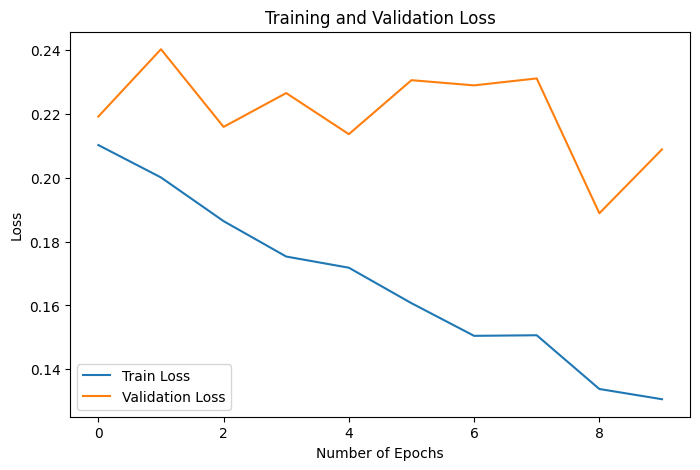

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Number of Epochs")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()


**9.** Test UNet Model

In [20]:
model.eval()

with torch.no_grad():

    image, mask = val_dataset[0]

    input_image = image.unsqueeze(0).to(device)

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = (prediction > 0.5).float()

    prediction = prediction.squeeze().cpu().numpy()

**10.** Display Sample Segmentation Prediction

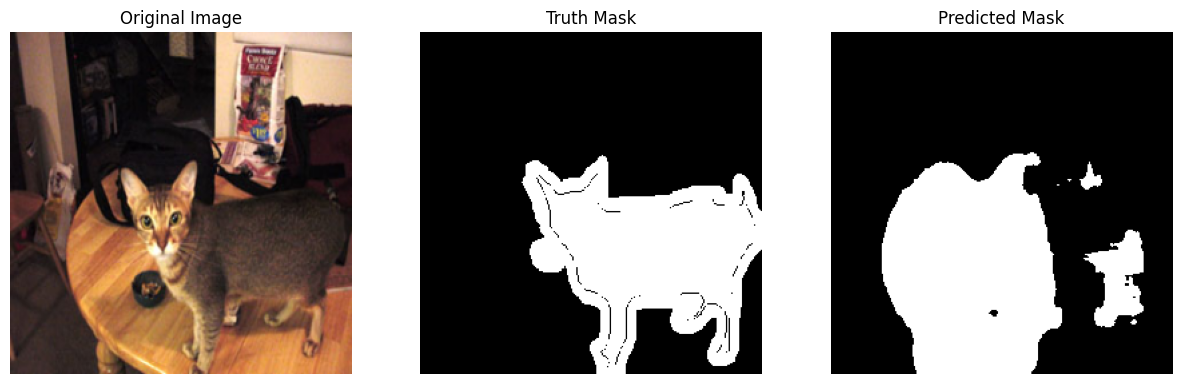

In [22]:
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Original Image")
plt.axis("off")

# Truth Mask
plt.subplot(1, 3, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Truth Mask")
plt.axis("off")

# Predicted Mask
plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")
plt.show()